# <u>DIGIT RECOGNIZER</u> 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
%matplotlib inline

np.random.seed(2)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense , Flatten , Conv2D , MaxPool2D , Dropout
from keras.optimizers import RMSprop
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
sns.set(style='white' , context='notebook' , palette='deep')



In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.7/252.7 MB 3.9 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 3.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 4.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.1/418.1 kB 4.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 5.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 6.1 MB/s eta 0:00:00


# Data preparation

In [13]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')


In [14]:
Y_train = train['label']

X_train = train.drop(columns=['label'] , axis=1)

del train 

sns.countplot(Y_train)
Y_train.value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

checking for missing values 

In [ ]:

X_train.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object

In [17]:
Y_train.isnull().describe()

count     42000
unique        1
top       False
freq      42000
Name: label, dtype: object

Normalization

In [18]:
X_train = X_train/255.0
test = test /255.0

Reshape

In [19]:
X_train = X_train.values.reshape(-1,28,28,1)
test =test.values.reshape(-1,28,28,1)

Label encoding

In [20]:
Y_train = to_categorical(Y_train , num_classes=10)

Split training and valdiation set

In [25]:
random_seed = 2

X_train , X_val , Y_train , Y_val = train_test_split(X_train,Y_train , random_state=random_seed , test_size=0.1)

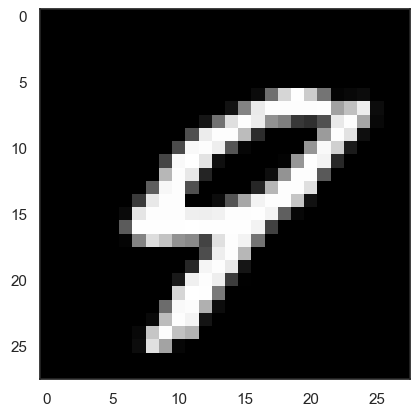

In [38]:
g = plt.imshow(X_train[0] [:,:,0] , cmap='grey')
plt.show()

In [27]:
g

CNN

In [53]:
# my CNN architechture is In -> [[Conv2D->relu]*2 -> MaxPool2D -> Dropout]*2 -> Flatten -> Dense -> Dropout -> Out

model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu', input_shape = (28,28,1)))
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))


In [57]:
# Define the optimizer
opt = RMSprop(learning_rate=0.001 , rho= 0.9 , epsilon=1e-08 , decay=0.0)

In [59]:
# Compile the model
model.compile(optimizer= opt, loss="categorical_crossentropy" , metrics=['accuracy']) 

In [60]:
# Set a learning rate annealer

learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc' , patience= 3, verbose=1 , factor= 0.5 , min_lr=0.00001)

In [61]:
epochs = 1
batch_size = 86

In [63]:
history = model.fit(X_train ,Y_train , batch_size= batch_size , epochs= epochs , verbose= 2 , validation_data=(X_val ,Y_val))

330/330 - 59s - 180ms/step - accuracy: 0.9737 - loss: 0.0870 - val_accuracy: 0.9857 - val_loss: 0.0481


# Evaluation

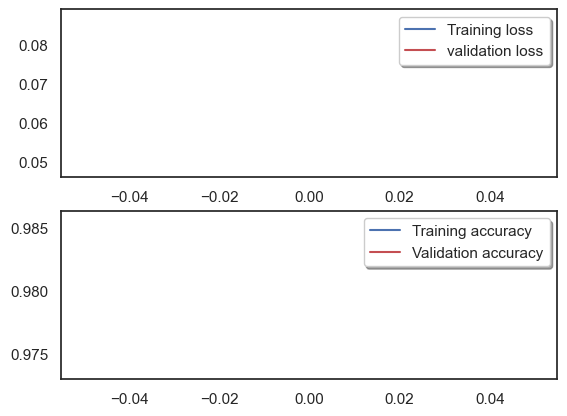

In [68]:
# Plot the loss and accuracy curves for training and validation 
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss")
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

plt.show()

99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


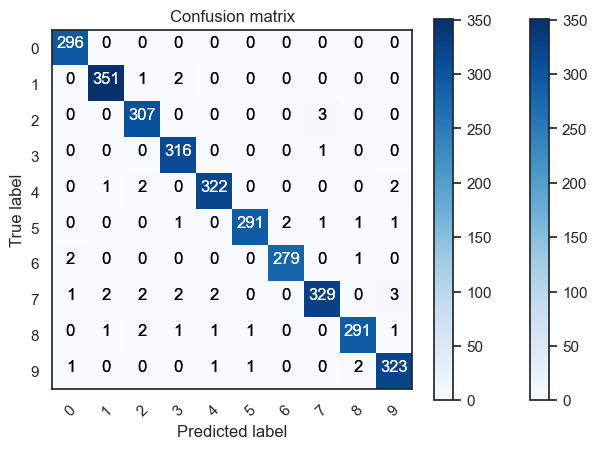

In [70]:
# Look at confusion matrix 

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Predict the values from the validation dataset
Y_pred = model.predict(X_val)
# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_pred,axis = 1) 
# Convert validation observations to one hot vectors
Y_true = np.argmax(Y_val,axis = 1) 
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 
# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(10)) 
plt.show()